## Modular Designs, Same Performance: Operability-Based Intensification of a Membrane Reactor (P1, P2, P3 and the Multilayer MILP)

Author: Victor Alves  - Carnegie Mellon University

This case study consists of a membrane reactor for direct methane aromatization (DMA-MR) that allows hydrogen and benzene production from natural gas. Beyond asking which designs are feasible, process intensification asks for the **smallest** (or cheapest) design that still delivers a desired level of performance. This tutorial walks through the complete family of operability-based design optimization problems on the DMA-MR:

- **P1**, the classic inverse mapping {cite}`carrasco16,carrasco2017`: from a Desired Output Set (DOS), compute the feasible desired input set (DIS*) and its outputs (DOS*) by minimizing the relative error to each DOS point;
- **P2**, process intensification {cite}`carrasco16,carrasco_thesis`: among the DIS* designs that satisfy a desired level of performance, select the one minimizing an intensification target $\Omega = \min \mathrm{PI}_{\mathrm{target}}$ (reactor volume, membrane area);
- **P3**, the bilevel operability framework {cite}`carrasco_bilevel,carrasco_thesis`: the nested program whose inner level is P1 and whose outer level minimizes the PI target, solved through its validated sequential equivalence;
- the **multilayer MILP** of Gazzaneo and Lima {cite}`gazzaneo18,gazzaneo19`: a mixed-integer linear program (MILP) over the multimodel polytope representation that finds the optimal modular design in seconds, iteratively refining the design space.

In this case study, some of opyrability's features are highlighted, such as:

-  Inverse mapping with the problem switch ``problem='P1' | 'P2' | 'P3'`` and a user-defined ``PI_target``
-  P2 as a postprocessing step on the P1 feasible region (rank the returned DIS*/DOS* by any intensification metric)
-  The MILP-based iterative design algorithm ``milp_based_approach`` (solved with the HiGHS solver bundled in scipy)
-  Automatic differentiation (JAX) for exact gradients in the inverse mapping

The schematic below {cite}`alves22` depicts the membrane reactor in a nutshell:

![](../images/dma-schematic.png)

The two design variables are the reactor length $u_1 = L$ [cm] and the tube diameter $u_2 = d_t$ [cm]; the outputs are the benzene production rate $y_1$ [mg/h] and the methane conversion $y_2$ [%]. For details on the first-principles model equations, see the [Membrane Reactor example](membrane_reactor.ipynb) in this gallery. The model is defined in full in the next cell so this notebook is self-contained (it is the same ``dma_mr_design`` that ships in opyrability's test suite).

**Variables:**

| Input (AIS/DIS) | Output (AOS/DOS) |
|---|---|
| Reactor length $L$ [cm] | Benzene production [mg/h] |
| Tube diameter $d_t$ [cm] | Methane conversion [%] |

In this case study, P1 will be solved over a DOS grid to obtain the DIS*/DOS* sets. Then, P2 will solve P1 internally and select the intensified design minimizing the reactor volume for a desired level of performance (benzene production of at least $20$ [mg/h]); because P2 returns the feasible region, a second metric (membrane area) is obtained by ranking that same region, with no extra solve. P3 will solve the same task as a single bilevel call, and finally the multilayer MILP will find the optimal modular design from scratch in fractions of a second. The plug-flow design constraint $L/d_t \geq 30$ {cite}`carrasco16` is enforced throughout.

Let's start by importing the packages and defining the DMA-MR design model:

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi as pi
import jax.numpy as jnp
from jax.experimental.ode import odeint

# --------------------------------------------------------------------------- #
# DMA-MR design model (self-contained copy of opyrability's test model
# tests/dma_mr.py). u = [L, dt] -> y = [benzene mg/h, CH4 conversion %].
# --------------------------------------------------------------------------- #

# Kinetic and general parameters.
R = 8.314e6                 # [Pa.cm3/(K.mol)]
k1 = 0.04                   # [s-1]
k1_Inv = 6.40e6             # [cm3/s-mol]
k2 = 4.20                   # [s-1]
k2_Inv = 56.38              # [cm3/s-mol]

MM_B = 78.00                # Benzene molecular weight [g/mol]

# Fixed reactor values.
T = 1173.15                 # Temperature [K] = 900 C (isothermal)
Q = 3600 * 0.01e-4          # [mol/(h.cm2.atm^0.25)]
selec = 1500                # Membrane selectivity

# Tube side.
Pt = 101325.0               # Pressure [Pa] (1 atm)
v0 = 3600 * (2 / 15)        # Volumetric flowrate [cm3/h]
Ft0 = Pt * v0 / (R * T)     # Initial molar flowrate [mol/h] - pure CH4

# Shell side.
Ps = 101325.0               # Pressure [Pa] (1 atm)
ds = 3                      # Diameter [cm]
v_He = 3600 * (1 / 6)       # Sweep gas volumetric flowrate [cm3/h]
F_He = Ps * v_He / (R * T)  # Sweep gas molar flowrate [mol/h]


def dma_mr_jax(F, z, dt):
    """Spatial molar balances (8 species: 4 tube + 4 shell), JAX-compatible."""
    At = 0.25 * jnp.pi * (dt ** 2)  # Cross-sectional area [cm2].

    # Avoid negative flows in the first integration steps (the ^0.25 terms
    # would otherwise produce complex numbers).
    F = jnp.where(F <= 1e-9, 1e-9, F)

    # Total flowrate in tube and shell.
    Ft = F[0:4].sum()
    Fs = F[4:].sum() + F_He
    v = v0 * (Ft / Ft0)

    # Concentrations [mol/cm3] and partial pressures (tube and shell).
    C = F[:4] / v
    P0t = (Pt / 101325) * (F[0] / Ft)
    P1t = (Pt / 101325) * (F[1] / Ft)
    P2t = (Pt / 101325) * (F[2] / Ft)
    P3t = (Pt / 101325) * (F[3] / Ft)
    P0s = (Ps / 101325) * (F[4] / Fs)
    P1s = (Ps / 101325) * (F[5] / Fs)
    P2s = (Ps / 101325) * (F[6] / Fs)
    P3s = (Ps / 101325) * (F[7] / Fs)

    # Reaction rates (guarded against near-zero concentrations).
    r0 = 3600 * k1 * C[0] * (1 - ((k1_Inv * C[1] * C[2] ** 2) /
                                  (k1 * (C[0]) ** 2)))
    r0 = jnp.where(C[0] <= 1e-9, 0, r0)
    r1 = 3600 * k2 * C[1] * (1 - ((k2_Inv * C[3] * C[2] ** 3) /
                                  (k2 * (C[1]) ** 3)))
    r1 = jnp.where(C[1] <= 1e-9, 0, r1)

    # Molar-balance adjustment with experimental data.
    eff = 0.9
    vb = 0.5
    Cat = (1 - vb) * eff

    # Molar balances dF/dz - tube (0 to 3) and shell (4 to 7).
    dF0 = -Cat * r0 * At - (Q / selec) * ((P0t ** 0.25) - (P0s ** 0.25)) * pi * dt
    dF1 = 1 / 2 * Cat * r0 * At - Cat * r1 * At - (Q / selec) * ((P1t ** 0.25) - (P1s ** 0.25)) * pi * dt
    dF2 = Cat * r0 * At + Cat * r1 * At - (Q) * ((P2t ** 0.25) - (P2s ** 0.25)) * pi * dt
    dF3 = (1 / 3) * Cat * r1 * At - (Q / selec) * ((P3t ** 0.25) - (P3s ** 0.25)) * pi * dt
    dF4 = (Q / selec) * ((P0t ** 0.25) - (P0s ** 0.25)) * pi * dt
    dF5 = (Q / selec) * ((P1t ** 0.25) - (P1s ** 0.25)) * pi * dt
    dF6 = (Q) * ((P2t ** 0.25) - (P2s ** 0.25)) * pi * dt
    dF7 = (Q / selec) * ((P3t ** 0.25) - (P3s ** 0.25)) * pi * dt

    return jnp.array([dF0, dF1, dF2, dF3, dF4, dF5, dF6, dF7])


def dma_mr_design(u):
    """DMA-MR design model: integrate the molar balances along the reactor."""
    L = u[0]                    # Tube length [cm].
    dt = u[1]                   # Tube diameter [cm].

    # Initial conditions: pure CH4 fed to the tube, empty shell.
    y0 = jnp.hstack((Ft0, jnp.zeros(7)))
    rtol, atol = 1e-10, 1e-10

    # Integrate the molar balances along the reactor (JAX Dormand-Prince).
    z = jnp.linspace(0, L, 2000)
    F = odeint(dma_mr_jax, y0, z, dt, rtol=rtol, atol=atol)

    F_C6H6 = (F[-1, 3] * 1000) * MM_B                  # Benzene [mg/h].
    X_CH4 = 100 * (Ft0 - F[-1, 0] - F[-1, 4]) / Ft0    # CH4 conversion [%].
    return jnp.array([F_C6H6, X_CH4])

### Problem P1: inverse mapping for the feasible design region

Defining the DOS (benzene production between $15$ and $25$ [mg/h], methane conversion between $35$ and $45$ [%]), the input bounds, and the plug-flow constraint. The inverse mapping is solved with Ipopt and JAX automatic differentiation.

Importing opyrability's inverse mapping (NLP-based) module:

In [2]:
from opyrability import nlp_based_approach

 You have selected automatic differentiation as a method for obtaining higher-order data (Jacobians/Hessian),
 Make sure your process model is JAX-compatible implementation-wise.


  0%|          | 0/25 [00:00<?, ?it/s]


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

P1 inverse mapping: 89 s for 25 DOS points


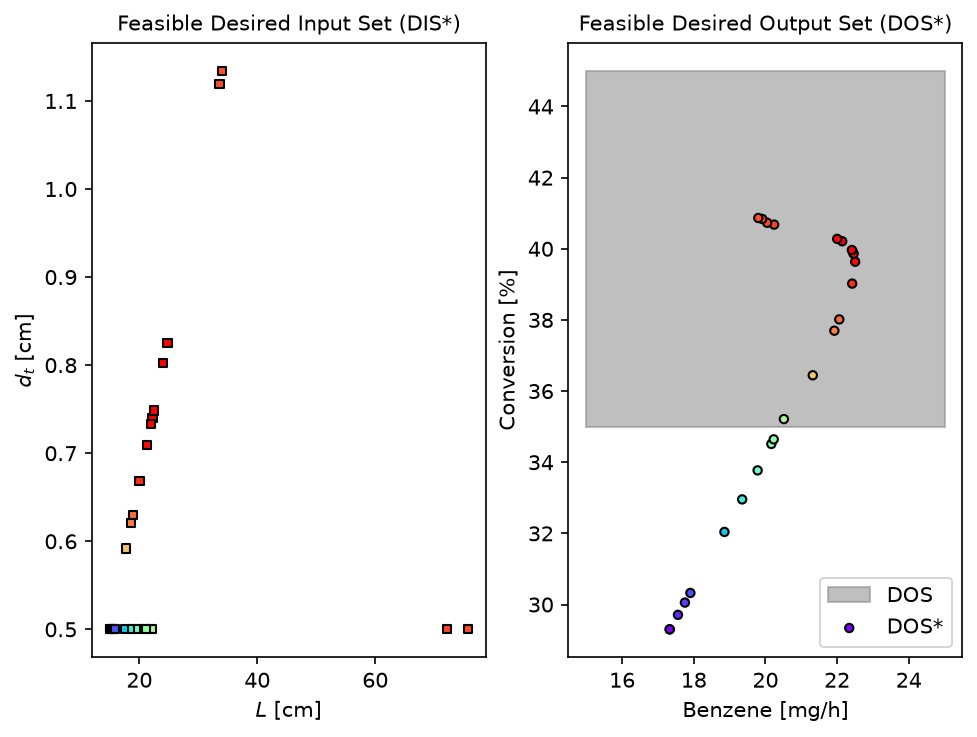

In [3]:
DOS_bounds = np.array([[15.0, 25.0],
                       [35.0, 45.0]])
DOS_resolution = [5, 5]

u0 = np.array([15.0, 1.0])     # Initial estimate [L, dt]
lb = np.array([10.0, 0.5])     # Lower bounds [cm]
ub = np.array([100.0, 2.0])    # Upper bounds [cm]

# Plug-flow design constraint: L / dt >= 30  ->  L - 30 dt >= 0
plug_flow = {'type': 'ineq', 'fun': lambda u: u[0] - 30.0 * u[1]}

start = time.time()
fDIS, fDOS, messages = nlp_based_approach(dma_mr_design,
                                          DOS_bounds,
                                          DOS_resolution,
                                          u0, 
                                          lb, 
                                          ub,
                                          constr=plug_flow,
                                          method='ipopt',
                                          ad=True,
                                          warmstart=True,
                                          plot=True,
                                          labels=['$L$ [cm]', '$d_t$ [cm]',
                                                  'Benzene [mg/h]',
                                                  'Conversion [%]'])
t_p1 = time.time() - start
print(f'P1 inverse mapping: {t_p1:.0f} s for {fDIS.shape[0]} DOS points')

### Problem P2: process intensification over the feasible designs

As an example, the level of operability level of performance is set as a benzene production rate of at least $20$ [mg/h]{cite}`carrasco_thesis`. The intensification target is the reactor volume, $\Omega_1 = \frac{\pi}{4} d_t^2 L$. ``problem='P2'`` solves the inner P1 over the DOS grid and then selects, among the feasible designs that meet the level of performance, the one with the smallest volume. P2 also returns the feasible region (``fDIS``, ``fDOS``); since the selection is pure postprocessing, a different intensification target (for example, the membrane area $\Omega_2 = \pi d_t L$) is obtained by ranking that same region directly, without re-solving P1:

 You have selected automatic differentiation as a method for obtaining higher-order data (Jacobians/Hessian),
 Make sure your process model is JAX-compatible implementation-wise.


  0%|          | 0/25 [00:00<?, ?it/s]

P2 (volume): L = 22.05 cm, dt = 0.50 cm, V = 4.33 cm3  (87 s)
P2 (area):   L = 17.76 cm, dt = 0.59 cm, A = 33.02 cm2  (ranked from the same region)


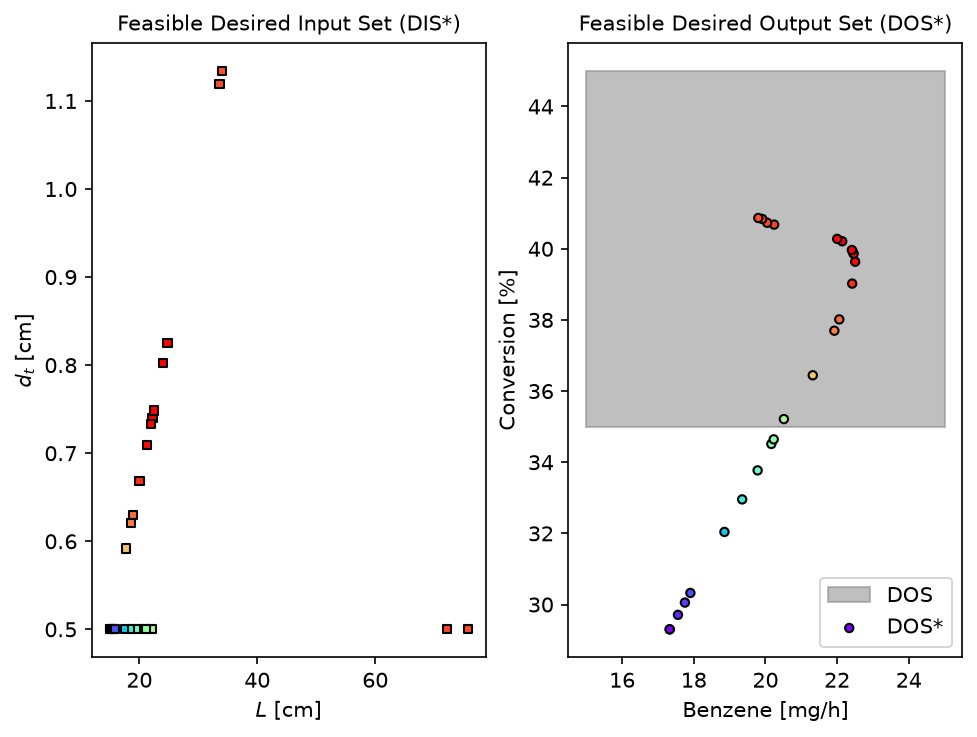

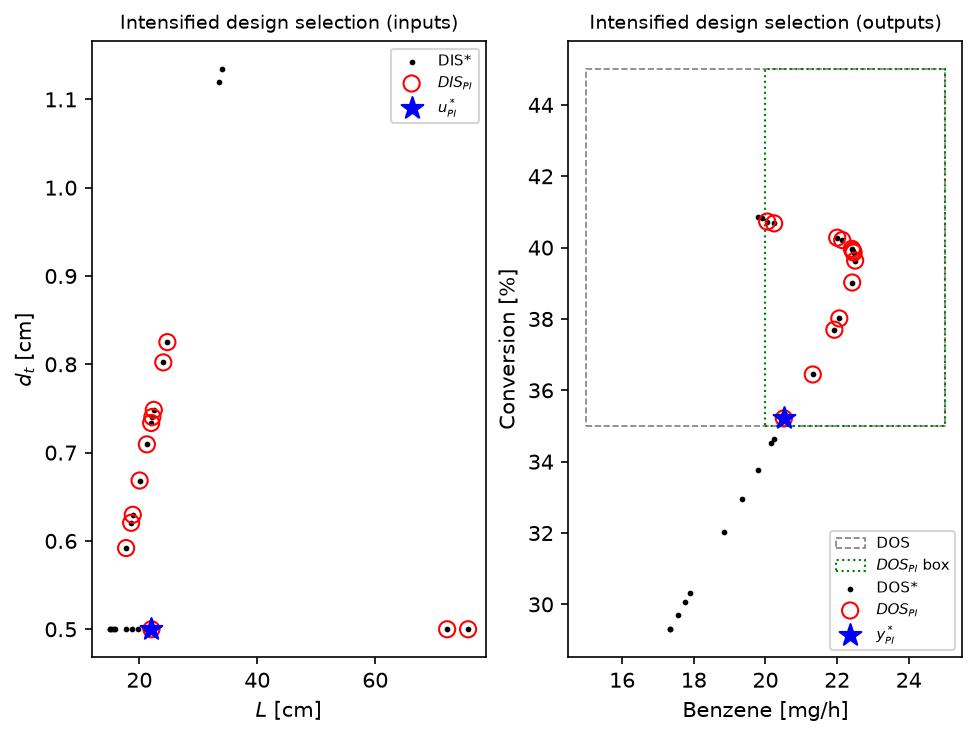

In [4]:
reactor_volume = lambda u: 0.25 * np.pi * u[1]**2 * u[0]   # [cm3]
membrane_area  = lambda u: np.pi * u[1] * u[0]              # [cm2]

PI_bounds = np.array([[20.0, 25.0],
                      [35.0, 45.0]])   # Level of performance: benzene >= 20

# P2 solves P1 internally, then selects the minimum-volume feasible design.
start = time.time()
fDIS_p2, fDOS_p2, _, report_volume = nlp_based_approach(dma_mr_design, 
                                                        DOS_bounds, 
                                                        DOS_resolution, 
                                                        u0, 
                                                        lb, 
                                                        ub,
                                                        constr=plug_flow, 
                                                        method='ipopt', 
                                                        ad=True, 
                                                        plot=True,
                                                        problem='P2', 
                                                        PI_target=reactor_volume, 
                                                        PI_bounds=PI_bounds,
                                                        labels=['$L$ [cm]', 
                                                                '$d_t$ [cm]', 
                                                                'Benzene [mg/h]', 
                                                                'Conversion [%]'])
t_p2 = time.time() - start

# P2 is postprocessing on its returned feasible region, so a second metric
# (membrane area) is obtained by ranking the SAME (fDIS_p2, fDOS_p2), no
# extra P1 solve required.
inside = np.all((fDOS_p2 >= PI_bounds[:, 0]) & (fDOS_p2 <= PI_bounds[:, 1]),
                axis=1)
dis_perf = fDIS_p2[inside]
area_vals = np.array([membrane_area(u) for u in dis_perf])
u_area = dis_perf[int(np.argmin(area_vals))]

print(f"P2 (volume): L = {report_volume['u_PI'][0]:.2f} cm, "
      f"dt = {report_volume['u_PI'][1]:.2f} cm, "
      f"V = {report_volume['PI_value']:.2f} cm3  ({t_p2:.0f} s)")
print(f"P2 (area):   L = {u_area[0]:.2f} cm, dt = {u_area[1]:.2f} cm, "
      f"A = {membrane_area(u_area):.2f} cm2  (ranked from the same region)")

The hollow red circles in the plot are the $DIS_{PI}$/$DOS_{PI}$ level-of-performance subsets and the star is the intensified design, mirroring Fig. 5.2 of {cite}`carrasco_thesis`. The selected design delivers the same performance class with a fraction of the footprint of the larger feasible designs, the central finding of the original study (about $77\%$ volume and $80\%$ membrane area reduction against the base case {cite}`carrasco16`).

### Problem P3: the bilevel operability framework

P3 nests P1 (inner level) inside the PI minimization (outer level):

$$\Psi = \min_{u \in \mathbb{U}}[\mathrm{PI}_{\mathrm{target}}] \quad \\
\text{s.t.} \quad u_k^* \in \underset{u_k^* \in \mathbb{U}_k,\; y_k \in DOS}{\mathrm{argmin}} \left\{\sum_{j=1}^n \left(\frac{y_{j,k} - y_{j,k}^*}{y_{j,k}}\right)^2\right\}, \\ 
\quad c_1(u_k^*) \leq 0$$

It is solved through its validated sequential equivalence: the outcome is the same as solving P1 and P2 in series over the full DOS grid{cite}`carrasco_thesis`. A single call solves the inner inverse mapping and the outer selection:

In [5]:
start = time.time()
_, _, _, report_p3 = nlp_based_approach(dma_mr_design, DOS_bounds,
                                        DOS_resolution, u0, lb, ub,
                                        constr=plug_flow,
                                        method='ipopt',
                                        ad=True,
                                        plot=False,
                                        problem='P3',
                                        PI_target=reactor_volume,
                                        PI_bounds=PI_bounds)
t_p3 = time.time() - start
print(f"P3 (bilevel): L = {report_p3['u_PI'][0]:.2f} cm, "
      f"dt = {report_p3['u_PI'][1]:.2f} cm, "
      f"V = {report_p3['PI_value']:.2f} cm3  ({t_p3:.0f} s)")
print(f"Same design as sequential P1 + P2: "
      f"{np.allclose(report_p3['u_PI'], report_volume['u_PI'], atol=1e-6)}")

 You have selected automatic differentiation as a method for obtaining higher-order data (Jacobians/Hessian),
 Make sure your process model is JAX-compatible implementation-wise.


  0%|          | 0/25 [00:00<?, ?it/s]

P3 (bilevel): L = 22.05 cm, dt = 0.50 cm, V = 4.33 cm3  (86 s)
Same design as sequential P1 + P2: True


### The multilayer MILP: optimal modular design in seconds

The multilayer operability framework of Gazzaneo and Lima {cite}`gazzaneo19` replaces the nonlinear inverse mapping with a mixed-integer linear program (MILP) over the multimodel polytope representation: the model is simulated on a coarse grid, the input-output data are triangulated into paired polytopes, the MILP's integer part picks the single polytope that can reach the desired outputs, and its continuous part locates the best design point inside that polytope; the input region is then zoomed in around that point and the whole step repeats on a finer grid, sharpening the design at each pass {cite}`gazzaneo18`. The MILP is solved with the HiGHS solver bundled inside scipy, so no additional installation is needed (these are already opyrability dependencies).

Importing opyrability's MILP-based design module:

In [6]:
from opyrability import milp_based_approach

MILP design: L = 21.69 cm, dt = 0.50 cm (0.6 s, 5 iterations)
  approximate volume = 4.26 cm3, true volume = 4.26 cm3
phi per iteration: [5.42, 4.28, 4.26, 4.26, 4.26]


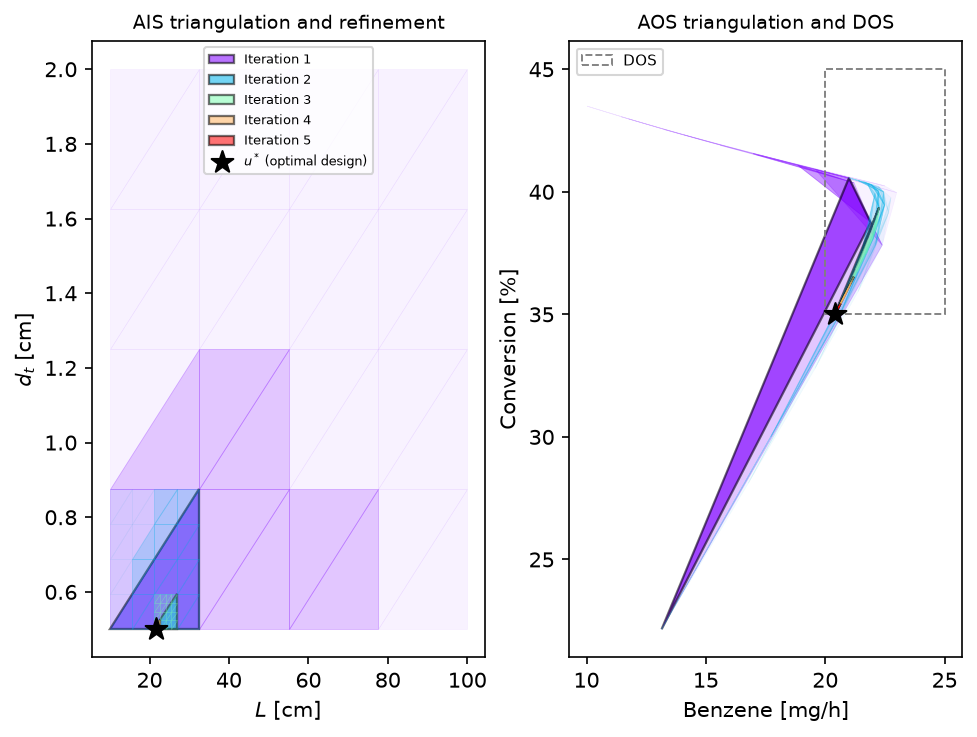

In [7]:
# Plug-flow constraint in linear form: L - 30 dt >= 0  ->  -L + 30 dt <= 0
A_u = np.array([[-1.0, 30.0]])
b_u = np.array([0.0])

MILP_AIS_Bounds = np.array([[10.0, 100.0], [0.5, 2.0]])
MILP_DOS_Bounds = np.array([[20.0, 25.0], [35.0, 45.0]])
start = time.time()
u_milp, y_milp, phi, phi_true, history = milp_based_approach(dma_mr_design,
                                                             AIS_bound=MILP_AIS_Bounds,
                                                             PI_target=reactor_volume,
                                                             DOS_bounds=MILP_DOS_Bounds,
                                                             AIS_resolution=5,
                                                             input_constr=(A_u, b_u),
                                                             labels=['$L$ [cm]', 
                                                                     '$d_t$ [cm]', 
                                                                     'Benzene [mg/h]', 
                                                                     'Conversion [%]'])
t_milp = time.time() - start

# milp_based_approach returns two volumes: the approximate one the MILP
# actually minimizes (built from the volume values at the polytope
# corners) and the true volume of the chosen design. They get closer as
# the polytopes shrink, and match here.
print(f"MILP design: L = {u_milp[0]:.2f} cm, dt = {u_milp[1]:.2f} cm "
      f"({t_milp:.1f} s, {len(history)} iterations)")
print(f"  approximate volume = {phi:.2f} cm3, true volume = {phi_true:.2f} cm3")
print('phi per iteration:', [round(h['phi'], 2) for h in history])

The iteration plot shows the winning polytope shrinking around the optimal design as the bounds are refined, and the objective decreases monotonically until the relative improvement falls below the tolerance, reproducing the behavior reported in {cite}`gazzaneo19` (where the 2x2 DMA-MR design converged in 5 iterations and a few seconds of CPU time).

### Comparing the approaches

In [8]:
rows = [
    ('P2 (intensification)', report_volume['u_PI'],
     report_volume['PI_value'], t_p2),
    ('P3 (bilevel, single call)', report_p3['u_PI'],
     report_p3['PI_value'], t_p3),
    ('Multilayer MILP', u_milp, phi_true, t_milp),
]
print(f"{'Approach':<30}{'L [cm]':>8}{'dt [cm]':>9}"
      f"{'Volume [cm3]':>14}{'Time [s]':>10}")
for name, u, v, t in rows:
    print(f"{name:<30}{u[0]:>8.2f}{u[1]:>9.2f}{v:>14.2f}{t:>10.1f}")

Approach                        L [cm]  dt [cm]  Volume [cm3]  Time [s]
P2 (intensification)             22.05     0.50          4.33      86.6
P3 (bilevel, single call)        22.05     0.50          4.33      86.1
Multilayer MILP                  21.69     0.50          4.26       0.6


### Conclusions

**Key Results:**

- P1 computed the feasible design region (DIS*/DOS*) of the DMA-MR for the desired production targets, with the plug-flow constraint enforced through the NLP.
- P2 solved P1 internally and selected the minimum-volume design meeting the benzene level of performance; the minimum-area design was then obtained by ranking the same returned feasible region, since the selection is pure postprocessing.
- P3 reproduced the same intensified design through the bilevel formulation, validating the sequential equivalence of {cite}`carrasco_thesis` on this problem.
- The multilayer MILP found an optimal modular design from scratch in about a second, two orders of magnitude faster than the NLP path, by exploiting the multimodel linearization {cite}`gazzaneo19`.

**Workflow Summary:**

1. Solve P1 (``nlp_based_approach``) over the DOS grid for the feasible design region.
2. Solve P2 (``problem='P2'`` with ``PI_target`` and ``PI_bounds``) to intensify; rank its returned region by any other metric for free.
3. Or solve P3 (``problem='P3'``) for the bilevel program in a single call.
4. Or run ``milp_based_approach`` for the MILP-based optimal modular design when speed matters.